In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('..')
sys.path.append('../gen_data/')
from utils import julio
import importlib
# importlib.reload(julio)
import pandas as pd
import src.observables as obs
importlib.reload(obs)
import utils.io as io
from read_corrs import read_corrs, select_dV
import matplotlib as mpl
mpl.style.use('aps.mplstyle')
import set_size_helper as ssh
# importlib.reload(ssh)

from scipy.fftpack import fft
from matplotlib.lines import Line2D

In [2]:
all_files = []
for N in (64, 128, 256, ):
    for dV in np.arange(3.2, 4.0, 0.05):
        filename = julio.corr_filename_builder(N, 1.0, 0.1, 0.8, dV=dV)
        if os.path.exists(filename):
            all_files.append(filename)
df = julio.load_correlations_files(all_files)

idmrg_file = '../../data/iDMRG/scanChi800/corrs/results.h5'
df_i = read_corrs(idmrg_file)

/tmp/ipykernel_194529/2383182260.py:15: RuntimeWarning: divide by zero encountered in power
  ax.plot(xarr, prefixes[j] * (xarr)**(-4/Ks), ls=':')


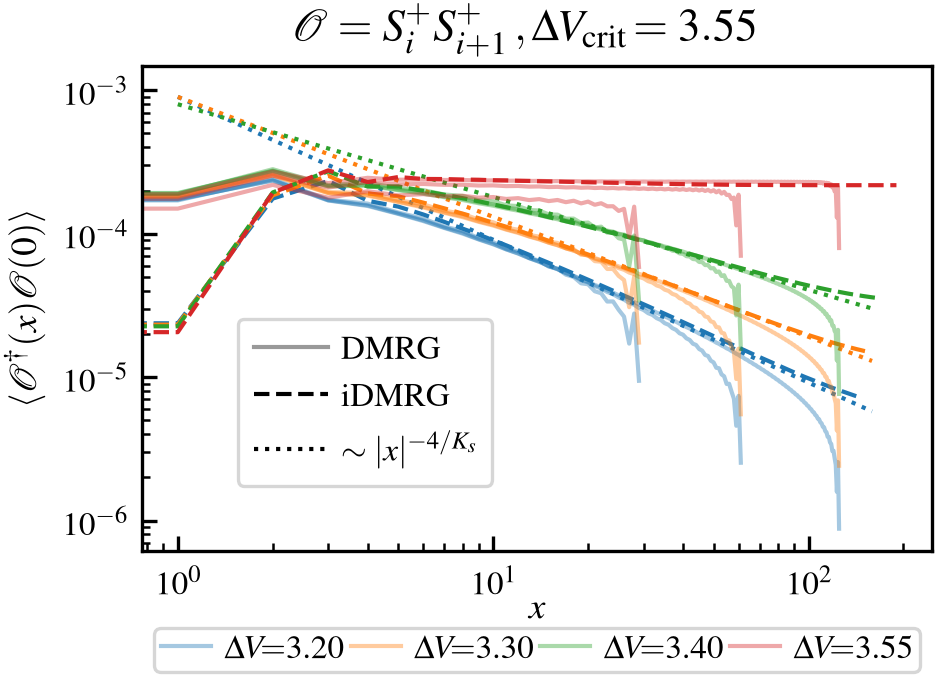

In [ ]:
fig, ax = plt.subplots(1)
dVvals = [3.2, 3.3, 3.4, 3.55, ]
prefixes = np.array([0.0009,0.0009, 0.0008, 1])
for j, dVval in enumerate(dVvals):
    col = f'C{j}'
    seldf_i = select_dV(df_i, dVval, atol=1e-7)
    ax.plot(np.abs(seldf_i["spin2_corr"].values[0]), c=col, ls='--', alpha=1.0) if not seldf_i.empty else None
    for nval in (64, 128, 256,):
        label = r'$\Delta V\!\!\!\!= $' + f'{dVval:.2f}' if nval==256 else None
        seldf = julio.select_N_dv_from_df(nval, dVval, df)
        ax.plot(np.abs(seldf["spin2vec"].values[0]), c=col, alpha=0.4, label=label)
        if dVval < 3.55 and nval == 256: 
            xarr = np.arange(160)
            Kc, Ks = obs.ret_Kc_Ks_from_seldf(seldf)
            ax.plot(xarr, prefixes[j] * (xarr)**(-4/Ks), ls=':')
        
ax.set_ylabel(r'$\langle \mathcal{O}^\dagger(x)\mathcal{O}(0)\rangle$')
ax.set_xlabel(r'$x$', labelpad=-2)
ax.set_xscale('log')
ax.set_yscale('log')

fig.suptitle(r"$ \mathcal{O} = S^+_iS^+_{i+1}\, , \Delta V_{\mathrm{crit}}\!= 3.55$")

handles, labels = ax.get_legend_handles_labels()
lgd = fig.legend(handles, labels, ncol=len(dVvals), columnspacing=0.2, labelspacing=0.2,
                 loc="lower center", bbox_to_anchor=(0.5, -0.25), 
                 frameon=True, fancybox=True, borderaxespad=0, 
                 bbox_transform=ax.transAxes)

# --- Internal legend ---
internal_handles = [
    Line2D([0], [0], color='black', lw=1.0, ls='-', alpha=0.4),
    Line2D([0], [0], color='black', lw=1.0, ls='--'),
    Line2D([0], [0], color='black', lw=1.0, ls=':')
]

internal_labels = [r'DMRG', 'iDMRG', r'$\sim |x|^{-4/K_s}$']

ax.legend(
    internal_handles, internal_labels,
    loc='lower left',  bbox_to_anchor=(0.10, 0.10),
    frameon=True, fancybox=True, borderpad=0.5, handlelength=2.2
)

# fig.savefig("figures/Show_LRO.pdf", bbox_inches='tight')

m = 0.2536433869361533
m = 0.27367172790999506
m = 0.3189288055622139
m = 0.7325900236843532


/tmp/ipykernel_273367/3073255336.py:31: RuntimeWarning: divide by zero encountered in power
  ax[0].plot(xarr, prefixes[j] * (xarr)**(powerlaw), ls=':')


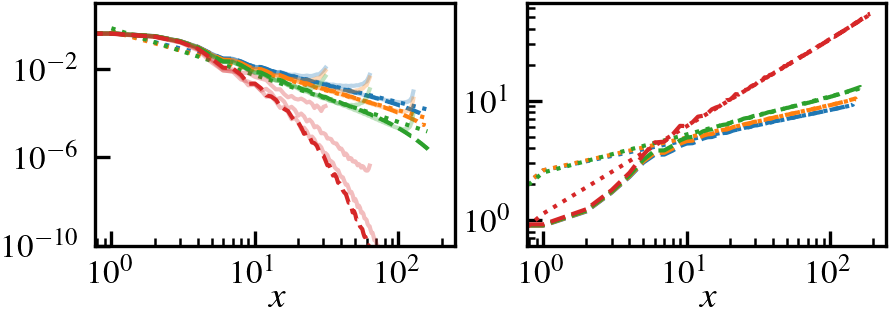

In [12]:
fig, ax = plt.subplots(1,2)
fig_dims = ssh.set_size(fraction=1.0, subplots=(1,2))
fig.set_size_inches(fig_dims)
dVvals = [3.2, 3.3, 3.4, 3.55, ]
prefixes = np.array([0.5, 0.5, 0.7, 1])
for j, dVval in enumerate(dVvals):
    col = f'C{j}'
    seldf_i = select_dV(df_i, dVval, atol=1e-7)
    yqty_i = np.abs(seldf_i["electron_corr"].values[0])
    yqty_i = obs.denoise_rolling(yqty_i, window=4)
    if np.isclose(dVval, 3.55) or True:
        logyqty_i = -np.log(yqty_i)
        xvals = np.arange(len(logyqty_i))
        fs = slice(20, -10)
        m, logc = np.polyfit(np.log(xvals[fs]), np.log(logyqty_i[fs]), 1)
        print(f'm = {m}')
        ax[1].plot(np.exp(logc) * xvals**m, c=col, ls=':', label=f'slope = {m:.3f}')
    ax[0].plot(yqty_i, c=col, ls='--', alpha=1.0) if not seldf_i.empty else None
    ax[1].plot(logyqty_i, c=col, ls='--', alpha=1.0) if not seldf_i.empty else None
    for nval in (64, 128, 256,):
        label = r'$\Delta V\!\!\!\!= $' + f'{dVval:.2f}' if nval==256 else None
        seldf = julio.select_N_dv_from_df(nval, dVval, df)
        yqty = np.abs(seldf["electron_conn"].values[0])
        yqty = obs.denoise_rolling(yqty, window=4)
        logyqty = -np.log(yqty)
        ax[0].plot(yqty, c=col, alpha=0.3, label=label)
        if dVval < 3.55 and nval == 256: 
            xarr = np.arange(160)
            Kc, Ks = obs.ret_Kc_Ks_from_seldf(seldf)
            powerlaw = -0.25 * (Kc + 1./Kc + Ks + 1./Ks)
            ax[0].plot(xarr, prefixes[j] * (xarr)**(powerlaw), ls=':')
        
# ax.set_ylabel(r'$\displaystyle\sum_{\sigma}\langle c^\dagger_\sigma(x)c^{\phantom\dagger}_\sigma(0)\rangle$')
ax[0].set_xlabel(r'$x$', labelpad=-2)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_ylim(1e-10,None)
ax[1].set_xlabel(r'$x$', labelpad=-2)
ax[1].set_xscale('log')
ax[1].set_yscale('log')

/tmp/ipykernel_194529/617750403.py:70: RuntimeWarning: divide by zero encountered in power
  prefixes[j] * xarr**(powerlaw),


dV = 3.55, m = 0.733


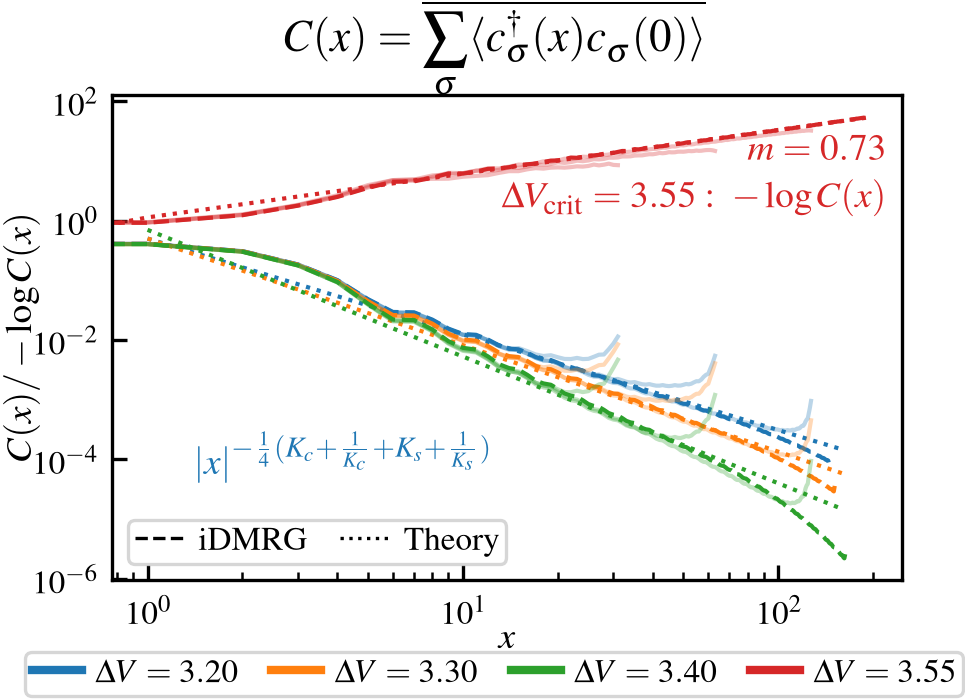

In [ ]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1)

dVvals = [3.2, 3.3, 3.4, 3.55]
prefixes = np.array([0.5, 0.5, 0.7, 1])

for j, dVval in enumerate(dVvals):
    col = f'C{j}'
    # ============================================================
    # iDMRG
    # ============================================================
    seldf_i = select_dV(df_i, dVval, atol=1e-7)
    if not seldf_i.empty:
        yqty_i = np.abs(seldf_i["electron_corr"].values[0])
        yqty_i = obs.denoise_rolling(yqty_i, window=4)

        # Special case: plot -log C
        if np.isclose(dVval, 3.55):
            yqty_i = -np.log(yqty_i)

            # Fit power law for the transformed quantity
            xvals = np.arange(len(yqty_i))
            fs = slice(20, -10)

            m, logc = np.polyfit(
                np.log(xvals[fs]),
                np.log(yqty_i[fs]),
                1
            )
            ax.plot(xvals, np.exp(logc) * xvals**m, c=col, ls=':')
            print(f'dV = {dVval:.2f}, m = {m:.3f}')

        ax.plot(
            yqty_i,
            c=col,
            ls='--',
            alpha=1.0,
        )
    # ============================================================
    # Finite DMRG
    # ============================================================
    for nval in (64, 128, 256):
        seldf = julio.select_N_dv_from_df(nval, dVval, df)
        if seldf.empty:
            continue
        yqty = np.abs(seldf["electron_conn"].values[0])
        yqty = obs.denoise_rolling(yqty, window=4)
        # Special case: plot -log C
        if np.isclose(dVval, 3.55):
            yqty = -np.log(yqty)

        ax.plot(
            yqty,
            c=col,
            alpha=0.3,
        )
        # ========================================================
        # Luttinger-liquid theory
        # ========================================================
        if dVval < 3.55 and nval == 256:
            xarr = np.arange(160)
            Kc, Ks = obs.ret_Kc_Ks_from_seldf(seldf)
            powerlaw = -0.25 * (
                Kc + 1. / Kc
                + Ks + 1. / Ks
            )
            ax.plot(
                xarr,
                prefixes[j] * xarr**(powerlaw),
                c=col,
                ls=':',
            )


# ================================================================
# Axes
# ================================================================

ax.set_xlabel(r'$x$', labelpad=-2)
ax.set_ylabel(r'$C(x)/-\log C(x)$', labelpad=-2)
ax.set_xscale('log')
ax.set_yscale('log')
fig.suptitle(
    r'$C(x) = \overline{\displaystyle\sum_\sigma '
    r'\langle c^\dagger_\sigma(x)c^{\phantom\dagger}_\sigma(0)\rangle}$',
    y=1.0275,
)
# ================================================================
# LEGENDS
# ================================================================
# Color = Delta V
color_handles = [
    Line2D(
        [0], [0],
        color=f'C{j}',
        lw=2,
        label=fr'$\Delta V={dV:.2f}$'
    )
    for j, dV in enumerate(dVvals)
]
# Line style = method / theory
style_handles = [
    Line2D(
        [0], [0],
        color='k',
        lw=0.8,
        ls='--',
        label='iDMRG',
    ),
    Line2D(
        [0], [0],
        color='k',
        lw=0.8,
        ls=':',
        label='Theory',
    ),
]
# ================================================================
# Main legend: line styles
# ================================================================
legend2 = ax.legend(
    handles=style_handles,
    ncol=2,
    loc='lower left',
    frameon=True,
    fancybox=True,
    columnspacing=1.0,
    handlelength=1.5,
)
# ================================================================
# Delta V legend BELOW the figure
# ================================================================
legend1 = fig.legend(
    handles=color_handles,
    ncol=len(dVvals),
    loc='lower center',
    bbox_to_anchor=(0.5, -0.1),
    frameon=True,
    fancybox=True,
    columnspacing=1.0,
    handlelength=1.5,
)
# ================================================================
# Annotations
# ================================================================
# Special transformed curve
ax.text(
    0.98, 0.75,
    r'$\Delta V_{\mathrm{crit}}=3.55:\;-\log C(x)$',
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=9,
    color='C3',             # same color as Delta V = 3.55
)
# Measured exponent
ax.text(
    0.98, 0.85,
    rf'$m={m:.2f}$',
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=9,
    color='C3',             # same color as the -log C curve
)
# LL prediction annotation
ax.text(
    0.48, 0.20,
    r'$|x|^{-\frac{1}{4}(K_c + \frac{1}{K_c} + K_s + \frac{1}{K_s})}$',
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=9,
    color='C0',             # color of one of the dotted LL curves
    style='italic',
)

# fig.savefig("figures/ShowLisaScaling.pdf", bbox_inches='tight')

#### $S^+$ QLROs at the critical point

Kc = 0.6803, Ks = -0.2371


/tmp/ipykernel_19894/1868511808.py:18: RuntimeWarning: divide by zero encountered in power
  ax.plot(xvals, prefix * xvals ** (-Kc), label=r'$\sim |x|^{-K_c}$', lw=0.7, c=colbos)


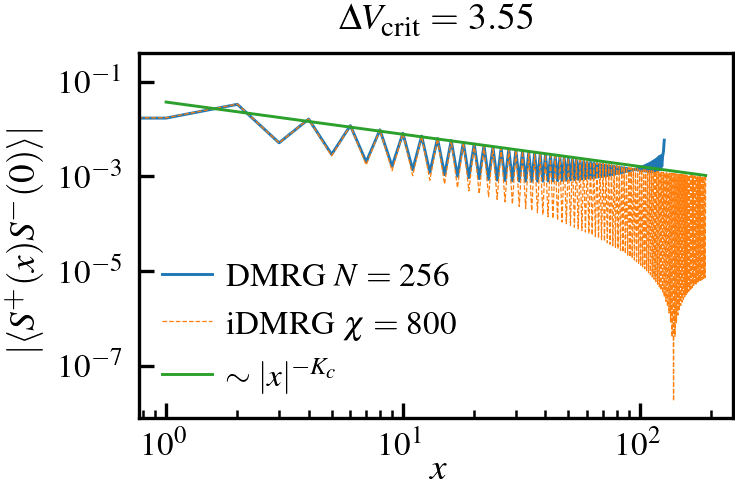

In [54]:
fig, ax = plt.subplots(1)
fig_size = ssh.set_size(subplots=(1,1), fraction=0.75)
fig.set_size_inches(fig_size)

colfd, colid, colbos = 'C0', 'C1', 'C2'

critseldf = julio.select_N_dv_from_df(256, 3.55, df)
Kc, Ks = obs.ret_Kc_Ks_from_seldf(critseldf)
print(f"Kc = {Kc:.4f}, Ks = {Ks:.4f}")
icritseldf = select_dV(df_i, 3.55, atol=1e-7)
yvals = icritseldf['spsm_corr'].iloc[0]
xvals = np.arange(len(yvals))
prefix = 1./(2 * np.pi**2)
prefix = 0.037

ax.plot(np.abs(critseldf['spmconn'].iloc[0]), lw=0.7, c=colfd, label=r'DMRG $N=256$')
ax.plot(xvals, np.abs(yvals), ls='--',lw=0.3, c=colid, label=r'iDMRG $\chi=800$')
ax.plot(xvals, prefix * xvals ** (-Kc), label=r'$\sim |x|^{-K_c}$', lw=0.7, c=colbos)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel(r'$|\langle S^+(x)S^-(0)\rangle|$')
ax.set_xlabel(r'$x$',labelpad=-2)
ax.legend()
ax.set_title(r'$\Delta V_{\mathrm{crit}} = 3.55$')
fig.savefig('figures/QLROSplusCrit.pdf', bbox_inches='tight')
